# Relation 1. Physics of Complex Systems. 

Diego Contreras Olmos

### Exercise 1: ENTROPY

• **Create several files with 1-million one-digit numbers and different amount of randomness**

    – A deterministic one in the format “11111111”.

    – A total random one.

    – One where the probability of a number is proportional to the number itself.

    – Any other distribution you can think of.


• **Calculate Shannon’s entropy of the files.**

• **Compress the files with ZIP and calculate the compression ratio.**

• **Plot the compression ratio against Shanon’s entropy. What is the relation between these two
quantities?**

• **Try to find a protocol that “cheats”, meaning that it has a high entropy but it can be efficiently
compressed.**


In [22]:
#Librerías

import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

In [23]:
#General parameters

Total_N = 1000000       #One million numbers
directorio = "entropy"  #Bin where we will store everything
os.makedirs(directorio, exist_ok=True)

#Create a function to save the numbers created by the different distributions

def savenumbers(file, number):
    """Save the number into the file 'file'

    Args:
        file (file): Where do you wanna store it?
        number (natural number): The number you wanna store
    """
    path = os.path.join(directorio, file)
    with open(path, "w") as f:
        f.write("".join(map(str, number)))      #This way the numbers are all together (I had to look it up)
    return path

In [24]:
#CODE: Distributions to generate numbers #############################################

#Create a void vector to put the info there
files = []

#1.- All are 1

number1 = np.ones(Total_N, dtype=int) #Use dtype to ensure they are not 1.0 #######################
path1 = savenumbers("1_all1.txt", number1)
files.append(("All_are_1", path1, number1))



#2.- Total random one: I believe this is equally probable from 0 to 9 ~#########################
number2 = np.random.randint(0,10, size=Total_N)
path2 = savenumbers("2_uniform.txt", number2)
files.append(("Uniformly random", path2, number2))



#3.- Proability proportional to the number itself. ##############################################

#Let us create a weighted distribution, linear in this case

valores3 = np.arange(10)
pesos3 = np.arange(1,11) #This way the number 0 can also appear
probabilidad3 = pesos3/pesos3.sum() #Normalize

number3 = np.random.choice(valores3, size=Total_N, p=probabilidad3)
path3 = savenumbers("3_proportional.txt", number3)
files.append(("Uniformly proportional", path3, number3))



#4.- My choice for distribution: Gaussian centered in 5

mu = 5
sigma = 1 #for example

number4 = np.random.normal(mu,sigma,size=Total_N) #this creates floats, let us round
number4 = np.round(number4) #We have whole numbers from -inf to +inf, we will take only from 0 to 9, because they are small, it will be negligible
number4 = np.clip(number4, 0, 9)    #Now we have natural numbers, but in the form of 0.0, 1.0, etc.
number4 = number4.astype(int)
path4 = savenumbers("4_gausiana.txt", number4)
files.append(("Gaussian distribution", path4, number4))




In [25]:
###CODE: SHANON ENTROPY ###############################

#Create a function to count the entropy

def shannon(number):
    """Calculate the shannon entropy of a file

    Args:
        number (vector): array of numbers

    Returns:
        _type_: the float H of the file
    """
    count=np.bincount(number)   #Counts how many times does a number appear
    prob = count[count >0] /len(number) #Calculate the probability as the counted number / 1000000 (in this case), the length
    H = -np.sum(prob*np.log2(prob))     #Shanon's entropy is defined as -Sum (P_i * log(P_i)) with the logarithm in base 2, bits
    return H


#Now, let us calculate the entropy of the files

for i, (name, path, number) in enumerate(files):
    H=shannon(number)
    files[i]=(name, path, number, H)

print("Entropy: ")
for name,path,number,H in files:
    print(f"{name:25s}, H= {H:.6f} bits")

Entropy: 
All_are_1                , H= -0.000000 bits
Uniformly random         , H= 3.321919 bits
Uniformly proportional   , H= 3.103696 bits
Gaussian distribution    , H= 2.105264 bits


In [26]:
###CODE: Compress the files using ZIP #######################

#Define a function to do so

def zip_file(file):
    """Compress using ZIP

    Args:
        file (file): the path of the file
    """
    zip_path = file.replace(".txt", ".zip")
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        zf.write(file, arcname=os.path.basename(file))
    return zip_path
    
#Create the ratio for the compression, i mean, the ration between weights of bits of the compressed and original files    

resultados = []

for name,path,digits,H in files:
    zip_path = zip_file(path)
    original_size = os.path.getsize(path)
    compressed_size = os.path.getsize(zip_path)
    c_ratio = compressed_size / original_size
    
    #Lets put this clean
    
    resultados.append({
        "name": name,
        "txt_path" : path,
        "zip_path": zip_path,
        "entropy" : H,
        "original_size" : original_size,
        "compressed_size" : compressed_size,
        "compression_ratio" : c_ratio
    })
    

print("Results: ")
for r in resultados:
    print(f"{r["name"]:25s}, H={r["entropy"]:.6f}, ratio = {r["compression_ratio"]:.6f}")


Results: 
All_are_1                , H=-0.000000, ratio = 0.001104
Uniformly random         , H=3.321919, ratio = 0.470594
Uniformly proportional   , H=3.103696, ratio = 0.449434
Gaussian distribution    , H=2.105264, ratio = 0.327283


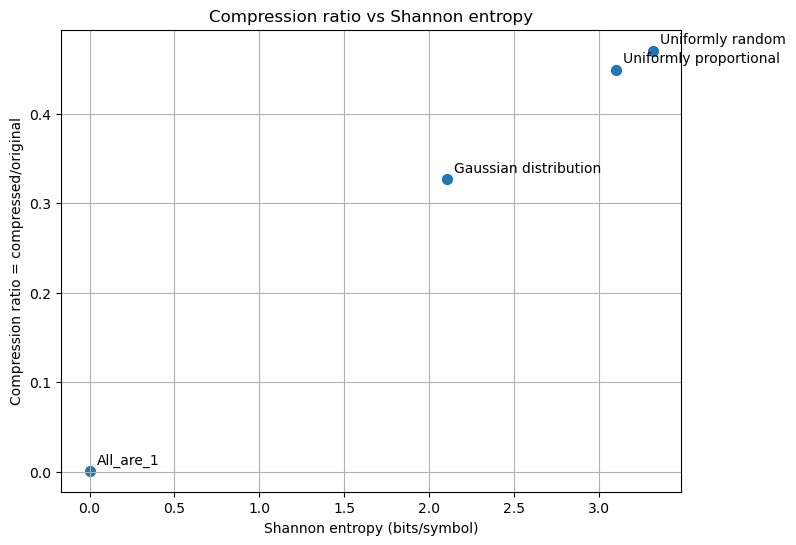

In [27]:
###CODE: PLOT the entropy vs the compression ratio ####################################

entropias = [r["entropy"] for r in resultados]
ratios = [r["compression_ratio"] for r in resultados]
labels = [r["name"] for r in resultados]

plt.figure(figsize=(8,6))
plt.scatter(entropias, ratios, s=50)

for x, y, label in zip(entropias, ratios, labels):
    plt.annotate(label, (x,y), xytext=(5,5), textcoords = "offset points")
    

plt.xlabel("Shannon entropy (bits/symbol)")
plt.ylabel("Compression ratio = compressed/original")
plt.title("Compression ratio vs Shannon entropy")
plt.grid()
plt.show()



In [ ]:
###CODE: Cheat method ############################

#We will abuse the definition of shannon's entropy. Zip can see more than just the repetition of the numbers, it sees at a larger scale (sort of).
#For that: create high entropy blocks that repeat.

chain_size = 1000
chain = np.random.randint(0, 10, size=chain_size)

repeats = Total_N // chain_size #Remember we set Total_N to a variable, so we have to know how many blocks we will have
number_cheat = np.tile(chain, repeats)

#If the blocks are not an exact divisor of Total_N, we add part of the chain
if len(number_cheat) < Total_N:
    number_cheat = np.concatenate([number_cheat, chain[:Total_N - len(number_cheat)]])
    

path_cheat = savenumbers("5_cheatcode.txt", number_cheat)
files.append(("Cheating algorithm (repetition)", path_cheat, number_cheat))

H_cheat = shannon(number_cheat)
zip_cheat = zip_file(path_cheat)
original_cheat = os.path.getsize(path_cheat)
compressed_cheat = os.path.getsize(zip_cheat)
ratio_cheat = compressed_cheat/original_cheat

print("Cheat algorithm: ")
print(f"Entropy = {H_cheat}:.6f bits")
print(f"Compression ratio = {ratio_cheat}:.6f")


#As we can see, compression ratio is almost null but entropy is high.

Cheat algorithm: 
Entropy = 3.315349931175242:.6f bits
Compression ratio = 0.00557:.6f
